## Loan Default Risk Prediction using Machine Learning

### Business Context

Financial institutions issue loans to customers, but a key challenge is identifying borrowers who are likely to default. Loan defaults can lead to significant financial losses.

By analyzing customer attributes such as income, employment history, loan details, and credit history, machine learning models can help predict the likelihood of default and support risk-based decision making.

### Problem Statement

Build a machine learning model to predict whether a customer will default on a loan based on their financial and credit-related attributes.

### Objective

Predict loan default (1 = default, 0 = non-default)

Identify high-risk applicants before loan approval

Minimize financial losses

Enable data-driven lending decisions

Improve model performance using appropriate evaluation metrics

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('credit_risk_dataset.csv')

In [ ]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
data.nunique()

,0
person_age,58
person_income,4295
person_home_ownership,4
person_emp_length,36
loan_intent,6
loan_grade,7
loan_amnt,753
loan_int_rate,348
loan_status,2
loan_percent_income,77


In [ ]:
data.shape

(32581, 12)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


#### Exploratory Data Analysis

In [ ]:
cat_cols = data.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"{col}: {data[col].unique()}")

person_home_ownership: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
loan_grade: ['D' 'B' 'C' 'A' 'E' 'F' 'G']
cb_person_default_on_file: ['Y' 'N']


In [ ]:
data.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


We see that the columns Employment length in years & loan interest rate have lots of missing values

In [ ]:
#To check for duplicate values
data.duplicated().sum()

np.int64(165)

In [ ]:
#Target variable distribution
data['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


We clearly notice imbalance in data where loan approval status is much lesser than rejected status

#### Univariate Analysis

In [ ]:
cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

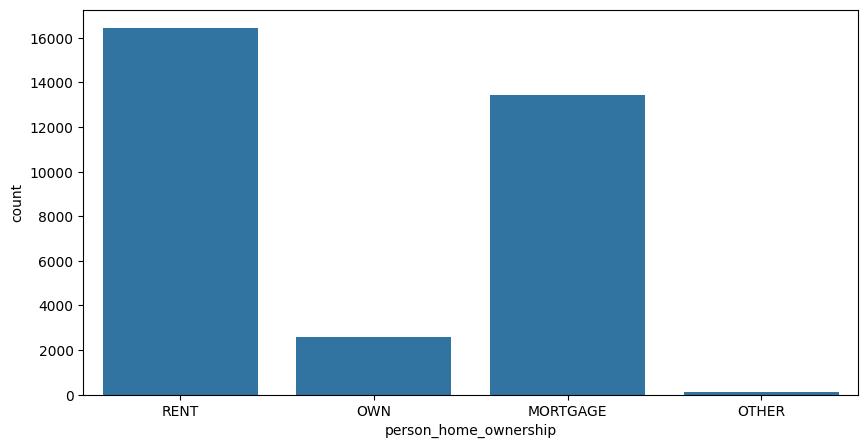

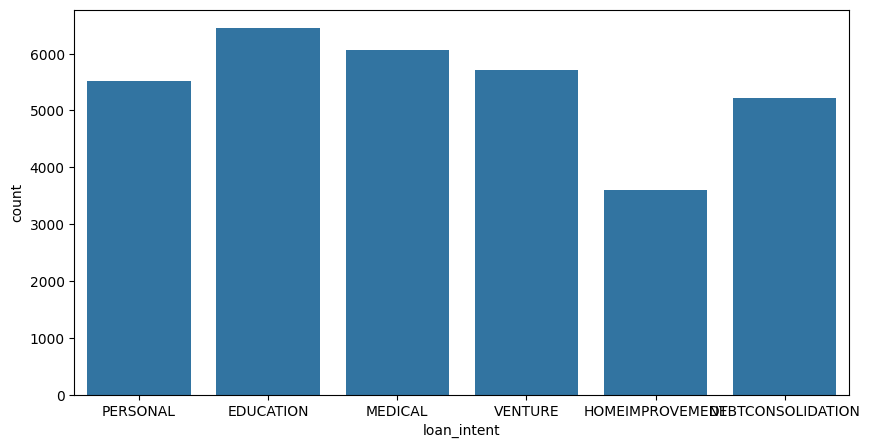

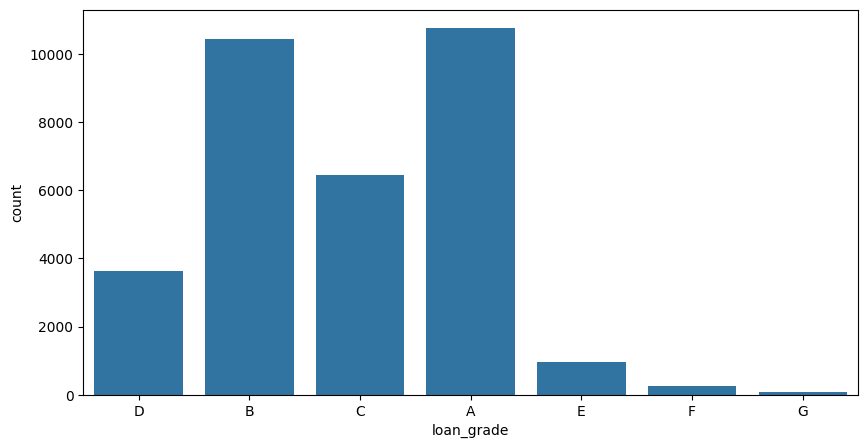

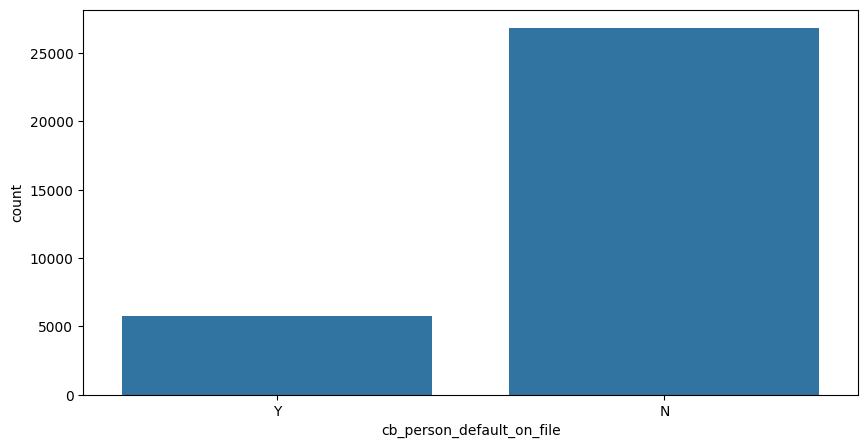

In [ ]:
for col in cat_cols:
  plt.figure(figsize=(10,5))
  sns.countplot(data=data, x=col)
  plt.show()

#### Observations -

We see that the Person home ownership is highest for Rent,shortly followed by Mortgage.

Loan intent indicates major borrowing purpose is education loans,least being home improvement

We see that most borrowers fall in low-risk category (A grade).

Historical deault is maximum N with few people defaulting (as Y)

In [ ]:
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'loan_status'
]

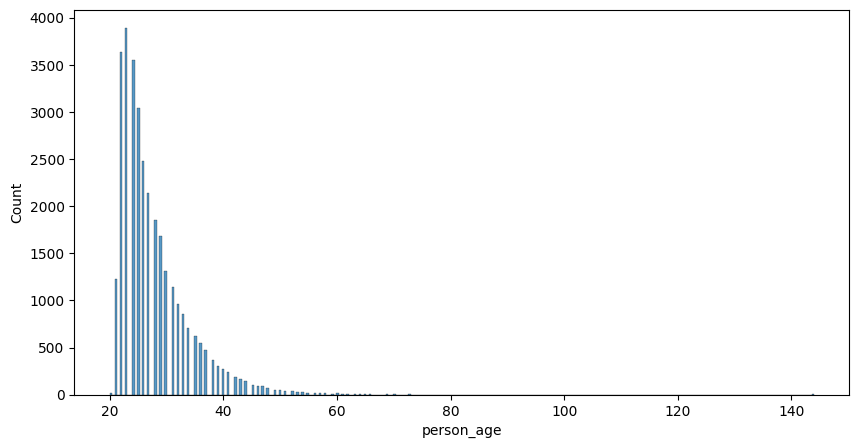

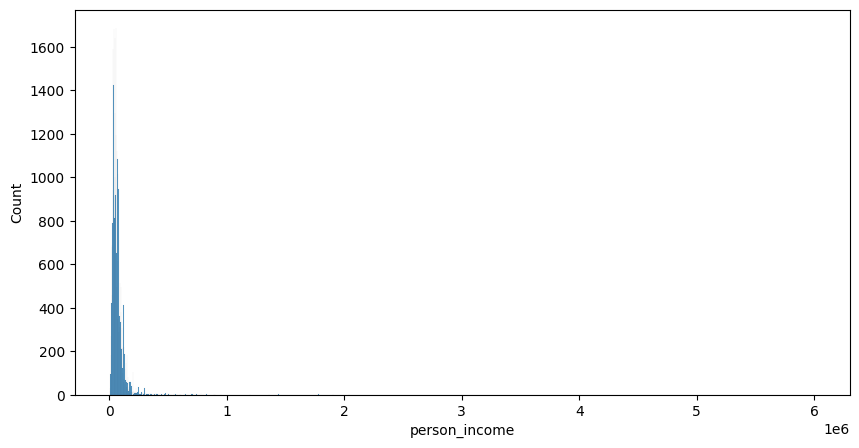

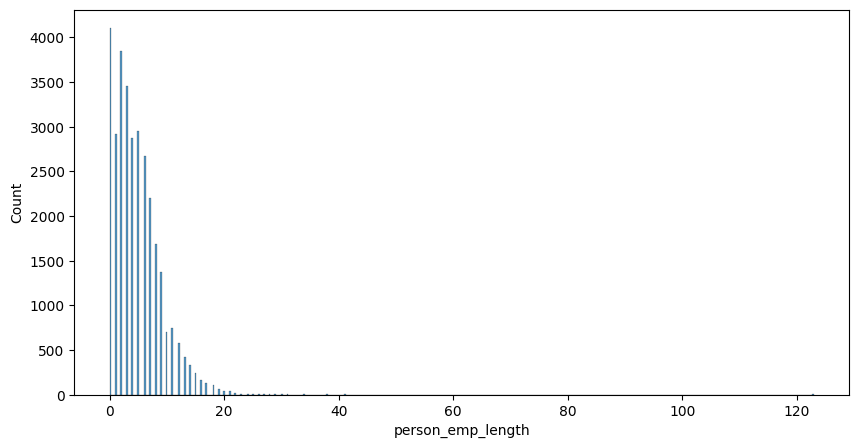

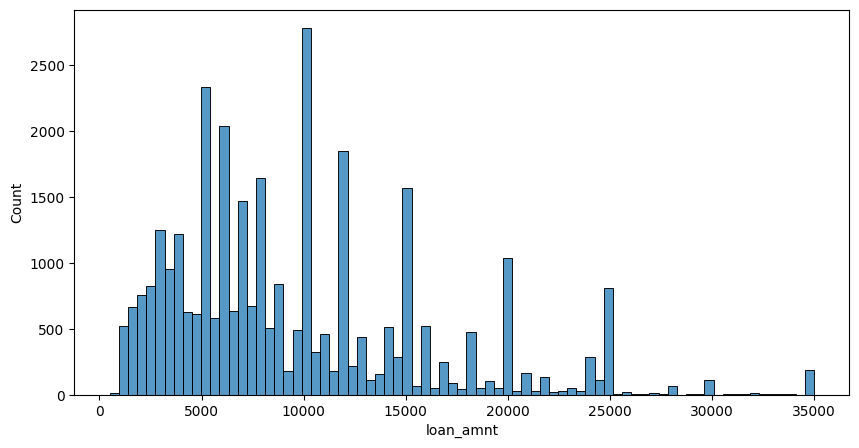

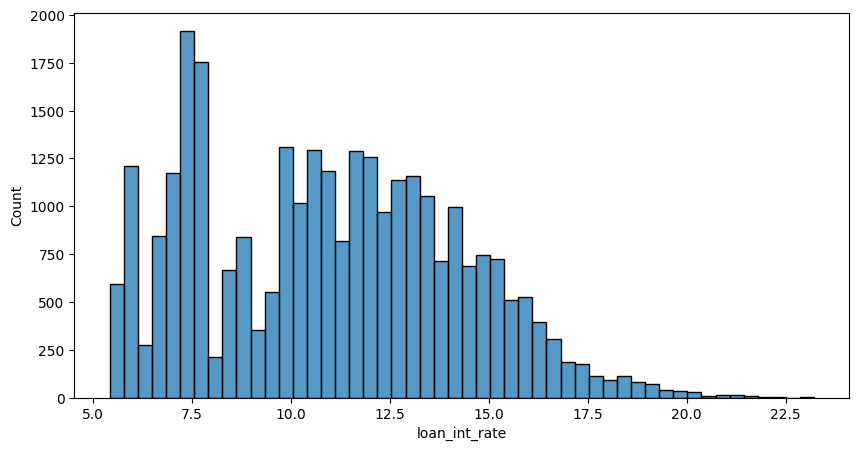

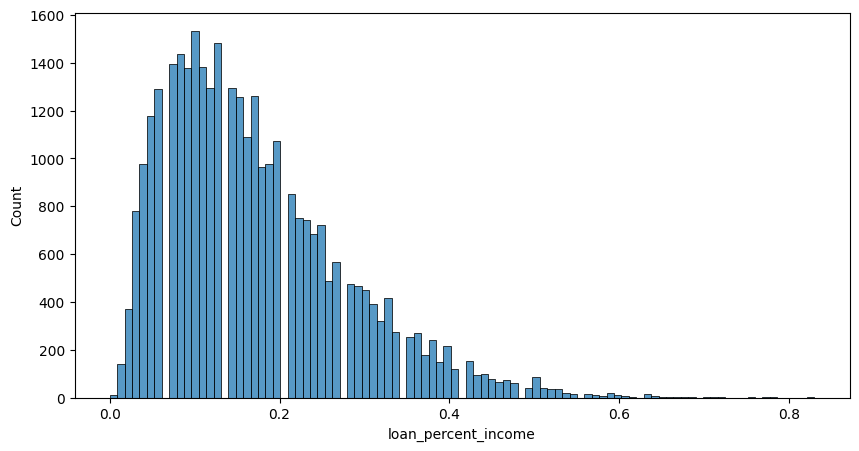

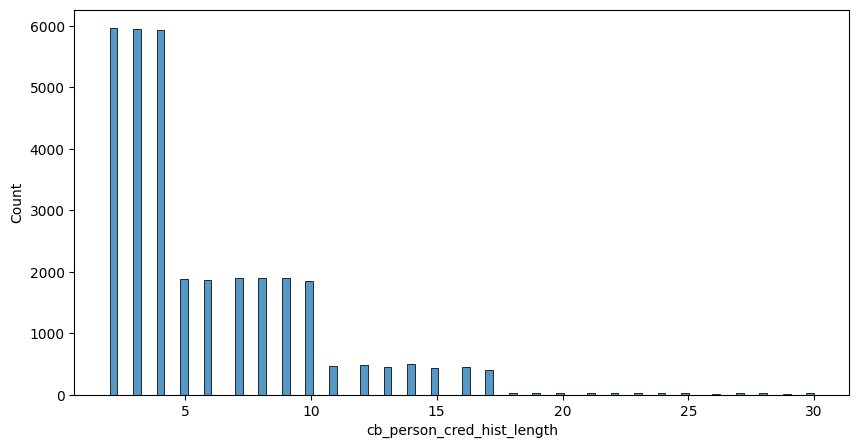

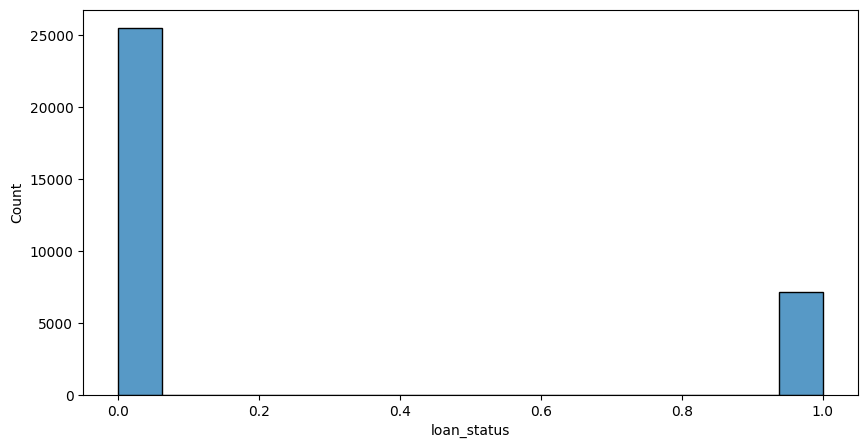

In [ ]:
for num in num_cols:
  plt.figure(figsize=(10,5))
  sns.histplot(data=data, x=num)
  plt.show()

#### Observations -
We see that age is concentrated in younger group (~20–30), indicating majority borrowers are early career individuals and date is right skewed

Person Income is right skewed, indicating most customers have lower income with few high earners, which may influence loan repayment ability.

Employment length seems to be right skewed with many borrowers have low experience → may impact repayment.

Loan amount is distributed across with highest being 10,000 dollars

Loan interest rate seems to be assorted with highest being 7.5%

Loan percent income where people spend ~10% of income on loan → affordability indicator.

Person's credit history is highest between 2 & 4 and has long tail on right (right skewed)

Loan status is non default by majority & has around 7000+ count being defaulted

### Bivariate Analysis

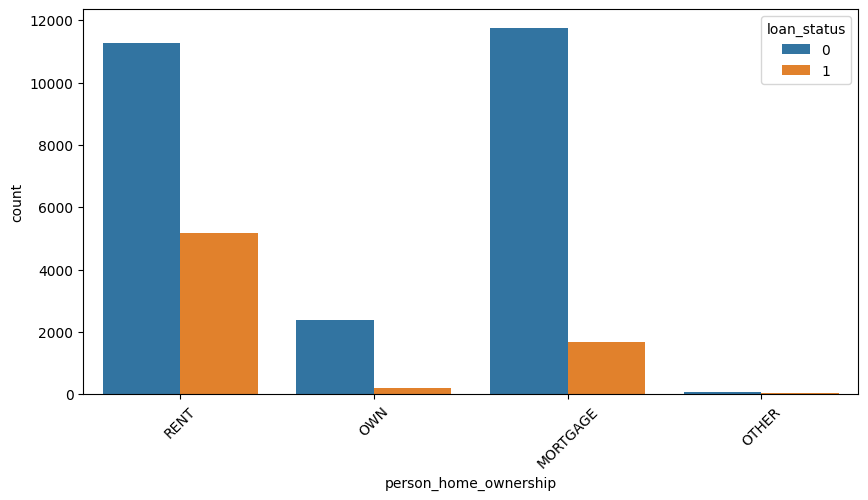

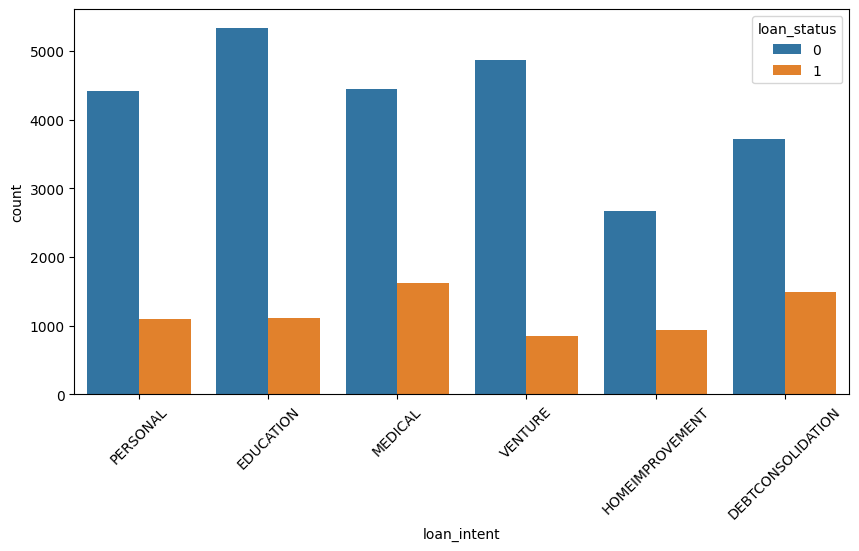

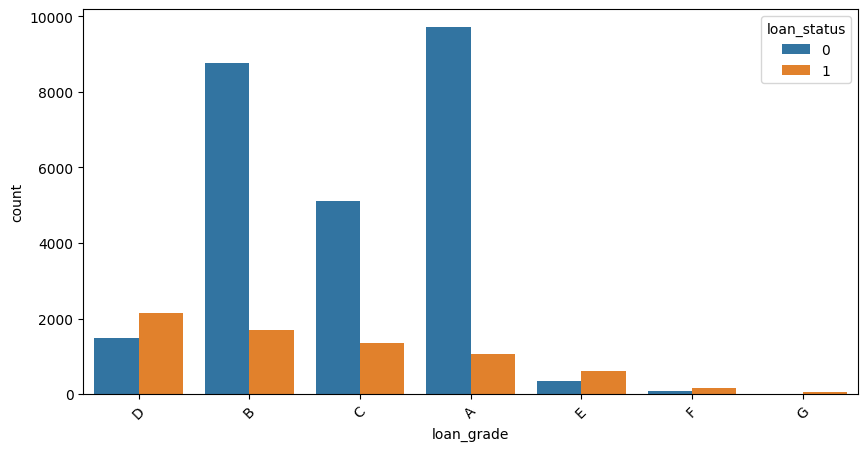

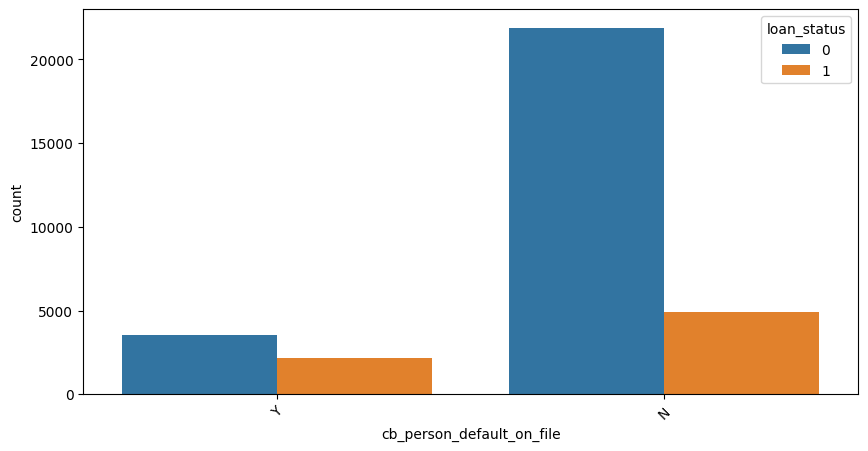

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=data, x=col, hue='loan_status')
    plt.xticks(rotation=45)
    plt.show()

#### Observations -

We can see the customers with mortgage ownership are more stable and show lower default rates, whereas renters show higher default risk.

Loan intent for Education has highest non defaulter, while Medical has highest defaulter loan status, emergency loans may indicate financial stress

Loan grade A has highest non defaulter while D has highest defaulter,confirms grading system reflects risk, it's lowest (both loan statuses) for G grade

Historical default shows Customers with previous defaults (Y) show higher likelihood of default, making it a strong predictive feature.

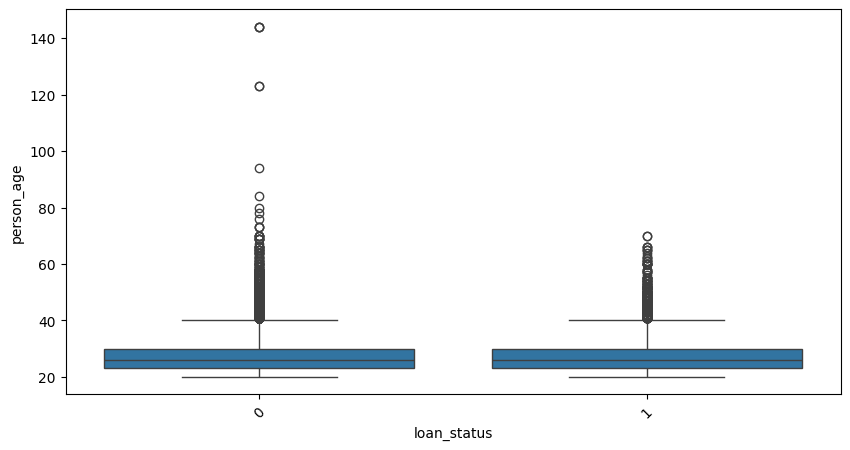

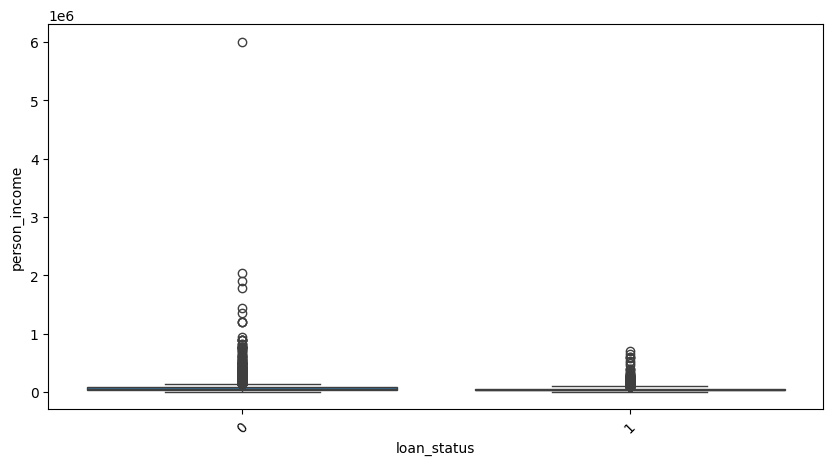

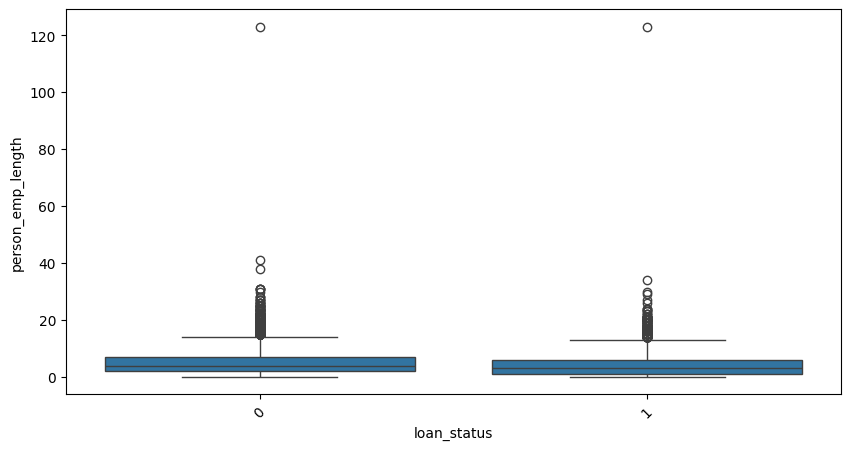

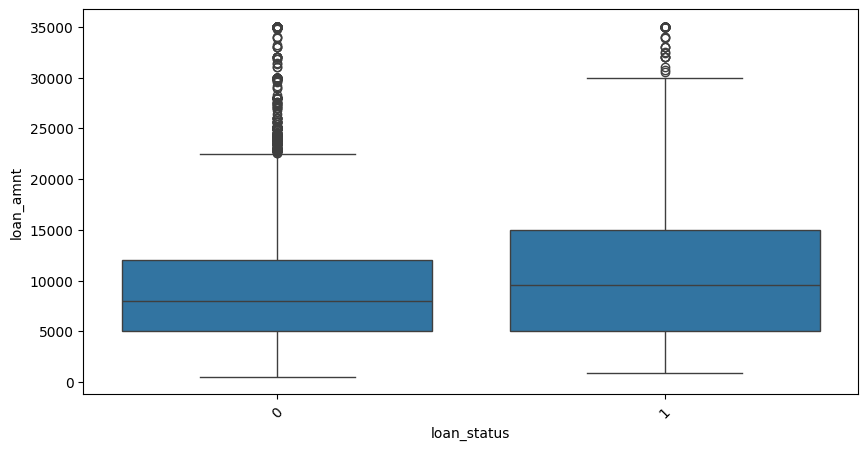

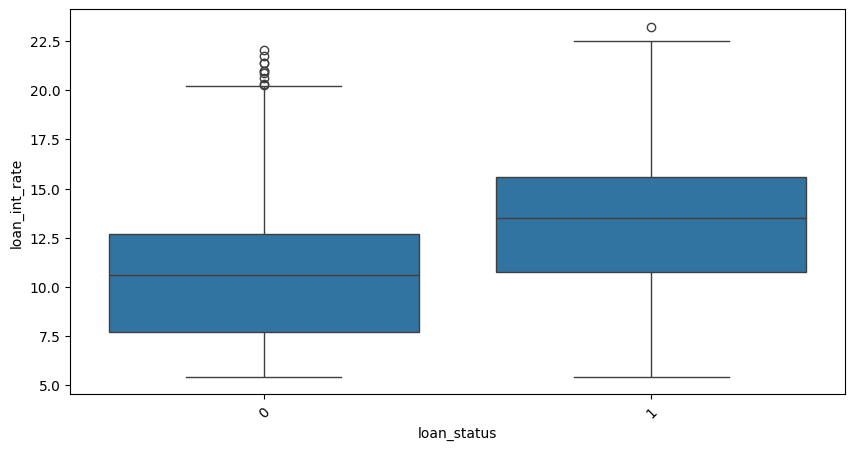

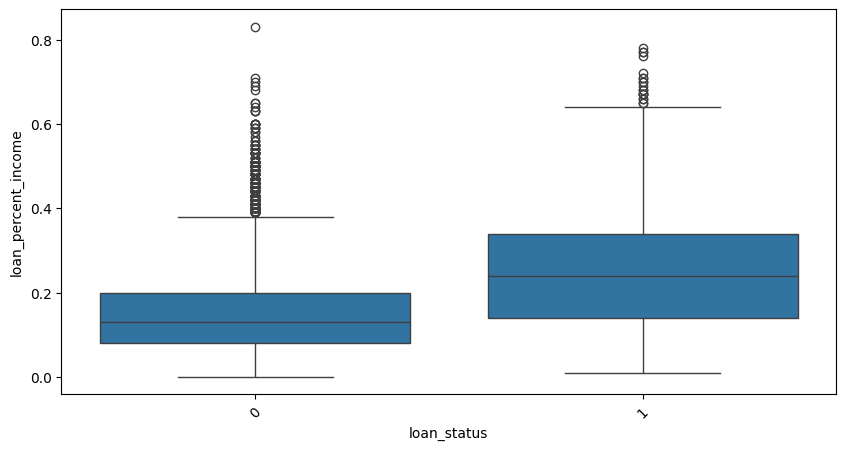

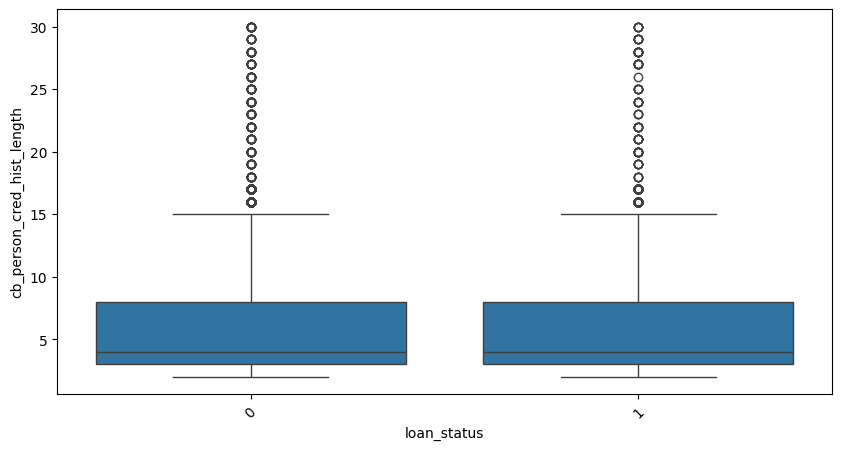

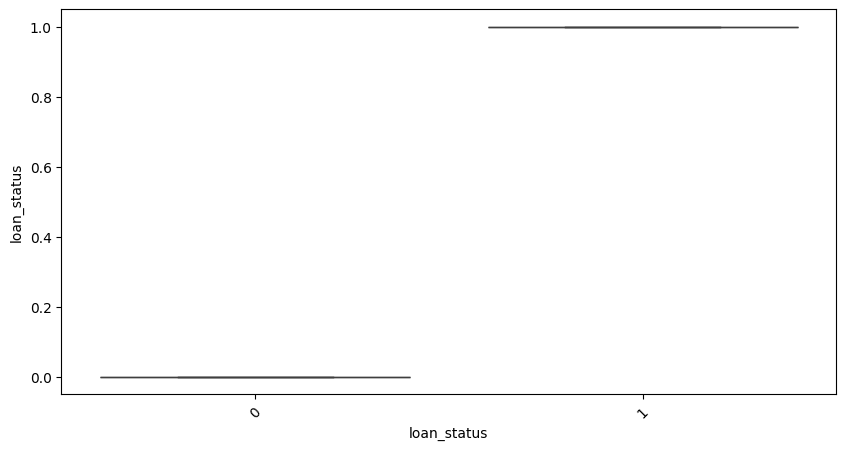

In [ ]:
for num in num_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=data, x='loan_status', y=num)
    plt.xticks(rotation=45)
    plt.show()

#### Observations -
 For person age, we see that there are quite a presence of extreme values for both loan statuses with non defaulter having wide outlier data & mean being somewhere around 30

We see outliers for Income aswell for both loan statuses

Employment length being a mean of around 5 months with presence of extreme values, highest ranging to even 120 months

Loan amount has outliers as well with mean around 7000-8000 dollars for both loan statuses

Loan interest rate for non defaulter has many extreme values while for defaulters have very less outlier data, with mean being around 10.5 for non defaulters while interest rate being higher with mean of around 13-13.5% for defaulters, Higher interest rates are associated with higher default risk, indicating risk-based pricing.

Loan % income has lower mean of 0.15% for non defaulters and around 0.25% for defaulters with more outliers for both, Higher loan-to-income ratio increases probability of default

There seems to be a steady pattern of outliers for credit history length for both loan statuses with mean less than 5



#### Missing values - Imputation

In [ ]:
# Fill missing values in 'person_emp_length' and 'loan_int_rate' with their respective medians
data['person_emp_length'].fillna(data['person_emp_length'].median(), inplace=True)
data['loan_int_rate'].fillna(data['loan_int_rate'].median(), inplace=True)

In [ ]:
data.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


We see that there are no more missing values in any of the columns

#### Encoding for categorical columns

In [ ]:
cat_encoding_cols = [
    'person_home_ownership',
    'loan_intent',
    'cb_person_default_on_file'
]

In [ ]:
data = pd.get_dummies(data, columns=cat_encoding_cols, drop_first=True)

In [ ]:
data.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,22,59000,123.0,D,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,True
1,21,9600,5.0,B,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,False
2,25,9600,1.0,C,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False
3,23,65500,4.0,C,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False
4,24,54400,8.0,C,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,True


In [ ]:
grade_mapping = {'A':1,
                 'B':2,
                 'C':3,
                 'D':4,
                 'E':5,
                 'F':6,
                 'G':7
                 }

data['loan_grade'] = data['loan_grade'].map(grade_mapping)
data.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,22,59000,123.0,4,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,True
1,21,9600,5.0,2,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,False
2,25,9600,1.0,3,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False
3,23,65500,4.0,3,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False
4,24,54400,8.0,3,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,True


In [ ]:
data['loan_grade'].isnull().sum()

np.int64(0)

We see there are no missing/unexpected values in Loan grade

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32581 non-null  int64  
 1   person_income                32581 non-null  int64  
 2   person_emp_length            32581 non-null  float64
 3   loan_grade                   32581 non-null  int64  
 4   loan_amnt                    32581 non-null  int64  
 5   loan_int_rate                32581 non-null  float64
 6   loan_status                  32581 non-null  int64  
 7   loan_percent_income          32581 non-null  float64
 8   cb_person_cred_hist_length   32581 non-null  int64  
 9   person_home_ownership_OTHER  32581 non-null  bool   
 10  person_home_ownership_OWN    32581 non-null  bool   
 11  person_home_ownership_RENT   32581 non-null  bool   
 12  loan_intent_EDUCATION        32581 non-null  bool   
 13  loan_intent_HOME

#### Handling outliers

In [ ]:
outlier_cols = [
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'person_emp_length'
]

In [ ]:
for col in outlier_cols:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  data[col] = np.where(data[col]>upper_bound,upper_bound,
              np.where(data[col]<lower_bound,lower_bound,data[col]))



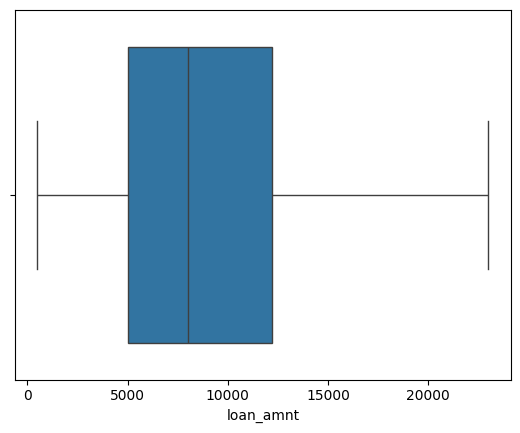

In [ ]:
sns.boxplot(data=data, x='loan_amnt')
plt.show()

#### Model Building

#### Train Test Split & Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Defining X & y
X = data.drop('loan_status', axis=1)
y = data['loan_status']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Logistic Regression

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)

In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:,1]
print(y_prob)

[0.11647252 0.06211549 0.00911387 ... 0.05463451 0.20188439 0.08771405]


In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

cm = confusion_matrix(y_test,y_pred)
print(cm)

[[4846  249]
 [ 684  738]]


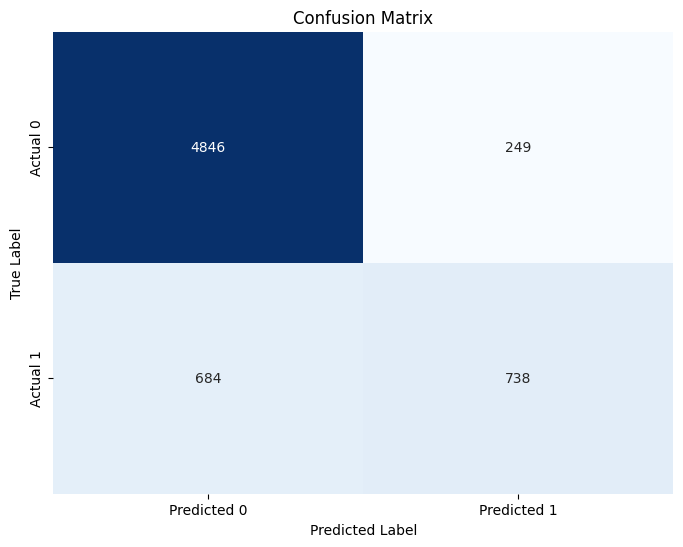

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      5095
           1       0.75      0.52      0.61      1422

    accuracy                           0.86      6517
   macro avg       0.81      0.74      0.76      6517
weighted avg       0.85      0.86      0.85      6517



#### Observations -

We see that the recall is only 52% , while accuracy is high at 86% .

The model has high accuracy but low recall for the default class, indicating it fails to identify a significant number of defaulters. Since missing defaulters is costly, we need to improve recall, possibly through threshold tuning or class imbalance handling.

#### Threshold Tuning

In [ ]:
#Note we have already mentioned y_prob = model.predict_proba(X_test_scaled)[:,1]
threshold = 0.35
y_pred_new = (y_prob >= threshold)
y_pred_new = y_pred_new.astype(int)

In [ ]:
y_pred_new

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
cm_tt = confusion_matrix(y_test,y_pred_new)
print(cm_tt)

[[4570  525]
 [ 476  946]]


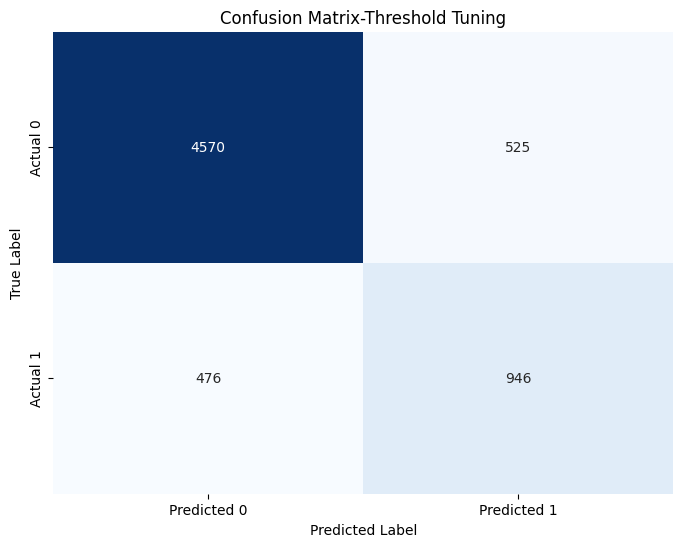

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix-Threshold Tuning')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
report_tt = classification_report(y_test,y_pred_new)
print(report_tt)

              precision    recall  f1-score   support

           0       0.91      0.90      0.90      5095
           1       0.64      0.67      0.65      1422

    accuracy                           0.85      6517
   macro avg       0.77      0.78      0.78      6517
weighted avg       0.85      0.85      0.85      6517



#### Observations -

We see that the recall has improved slightly and accuracy is higher as well.By lowering the threshold, recall improved significantly, reducing false negatives and helping identify more defaulters. Although precision decreased due to more false positives, this trade-off is acceptable in financial risk scenarios where missing defaulters is more costly.

#### PR Curve

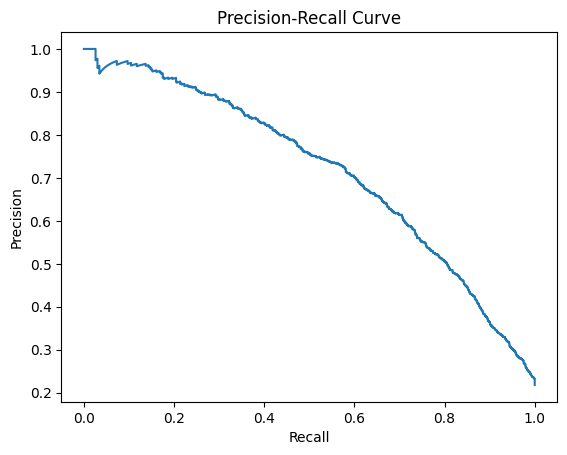

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
for i in range(len(thresholds)):
    print(thresholds[i], precision[i], recall[i])

0.0009081433836816801 0.21819855761853613 1.0
0.0010751283392140434 0.21823204419889503 1.0
0.0010886279160573235 0.2182655410590944 1.0
0.0011017251523123062 0.21829904820386858 1.0
0.0011163388960594783 0.21833256563795486 1.0
0.0012419250769919522 0.21836609336609336 1.0
0.001336961080425772 0.21839963139302718 1.0
0.001373144935329786 0.2184331797235023 1.0
0.0013809872698356156 0.21846673836226763 1.0
0.0014164158550733796 0.218500307314075 1.0
0.0014175576221725475 0.21853388658367912 1.0
0.0014215363882874572 0.2185674761758377 1.0
0.0015687479321438286 0.2186010760953113 1.0
0.0015720232756264829 0.21863468634686348 1.0
0.001601898301835539 0.21866830693526065 1.0
0.0016075280333425446 0.21870193786527223 1.0
0.0016211347696447873 0.21873557914167052 1.0
0.001703259962190143 0.21876923076923077 1.0
0.0017270864493896412 0.21880289275273118 1.0
0.001796334674637169 0.2188365650969529 1.0
0.0017991833712862695 0.21887024780668002 1.0
0.001809711665647521 0.2189039408866995 1.0
0.

In [ ]:
for i in range(len(thresholds)):
    if recall[i] >= 0.65 and precision[i] >= 0.60:
        print(f"Threshold: {thresholds[i]:.2f}, Precision: {precision[i]:.2f}, Recall: {recall[i]:.2f}")

Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.30, Precision: 0.60, Recall: 0.71
Threshold: 0.

#### Observation -

A threshold of 0.30 provides higher recall, allowing the model to identify more defaulters, which is critical in financial risk scenarios. Although precision decreases slightly, the trade-off is acceptable as minimizing false negatives is more important.

### Conclusion

The Logistic Regression model achieved strong overall performance with high accuracy but initially showed low recall for default cases. Through threshold tuning, recall was significantly improved from ~52% to ~71%, enabling better identification of high-risk customers. This demonstrates the importance of optimizing decision thresholds rather than relying solely on default model outputs.

### Recommendations

Prioritize recall to ensure maximum identification of potential defaulters

Use the model to flag high-risk customers before loan approval

Apply stricter verification or higher interest rates for predicted defaulters

Accept a moderate increase in false positives to reduce financial loss

Continuously monitor model performance and retrain with new data

### KNN Neighbor

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn=model_knn.predict(X_test_scaled)
y_prob_knn=model_knn.predict_proba(X_test_scaled)[:,1]

print(y_pred_knn)
print(y_prob_knn)

[0 0 0 ... 0 0 0]
[0.  0.  0.  ... 0.4 0.4 0.2]


In [ ]:
cm_knn = confusion_matrix(y_test,y_pred_knn)
print(cm_knn)

[[4950  145]
 [ 584  838]]


In [ ]:
report_knn = classification_report(y_test,y_pred_knn)
print(report_knn)

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      5095
           1       0.85      0.59      0.70      1422

    accuracy                           0.89      6517
   macro avg       0.87      0.78      0.81      6517
weighted avg       0.89      0.89      0.88      6517



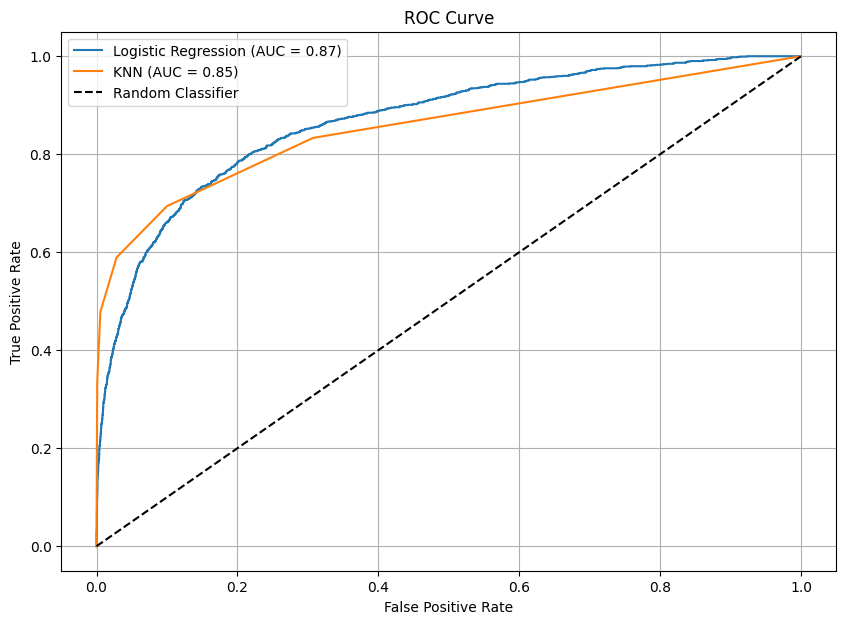

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob)
auc_lr = roc_auc_score(y_test, y_prob)

fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

#### Observations
The ROC curve shows how well the model distinguishes between the two classes. A higher AUC score indicates better performance. Both Logistic Regression and KNN models are performing better than a random classifier. Comparing the AUC scores, we see that the Logistic regression performs marginally better than KNN

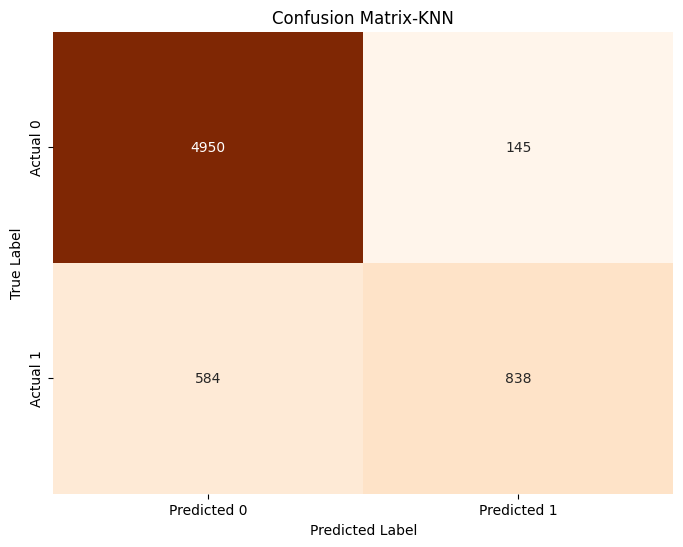

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix-KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Observations -
The KNN model shows high precision but relatively lower recall, indicating that while its predictions are reliable, it misses a significant number of defaulters. This makes it less suitable for risk-sensitive scenarios where identifying defaulters is critical.


--- Results for k = 3 ---
Predicted labels: [0 0 0 ... 0 0 0]
Predicted probabilities: [0. 0. 0. ... 0. 0. 0.]
Confusion Matrix:
 [[4878  217]
 [ 567  855]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93      5095
           1       0.80      0.60      0.69      1422

    accuracy                           0.88      6517
   macro avg       0.85      0.78      0.81      6517
weighted avg       0.87      0.88      0.87      6517



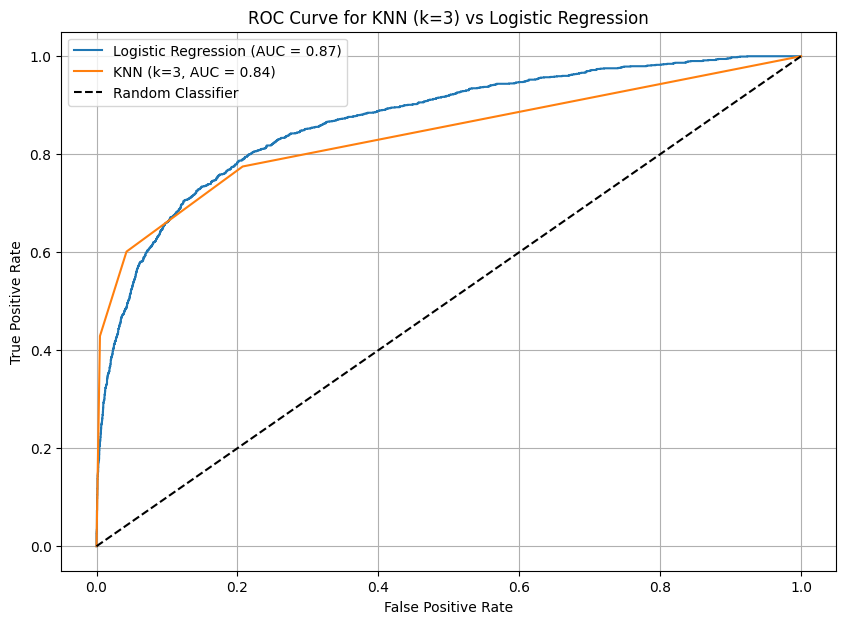


--- Results for k = 5 ---
Predicted labels: [0 0 0 ... 0 0 0]
Predicted probabilities: [0.  0.  0.  ... 0.4 0.4 0.2]
Confusion Matrix:
 [[4950  145]
 [ 584  838]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93      5095
           1       0.85      0.59      0.70      1422

    accuracy                           0.89      6517
   macro avg       0.87      0.78      0.81      6517
weighted avg       0.89      0.89      0.88      6517



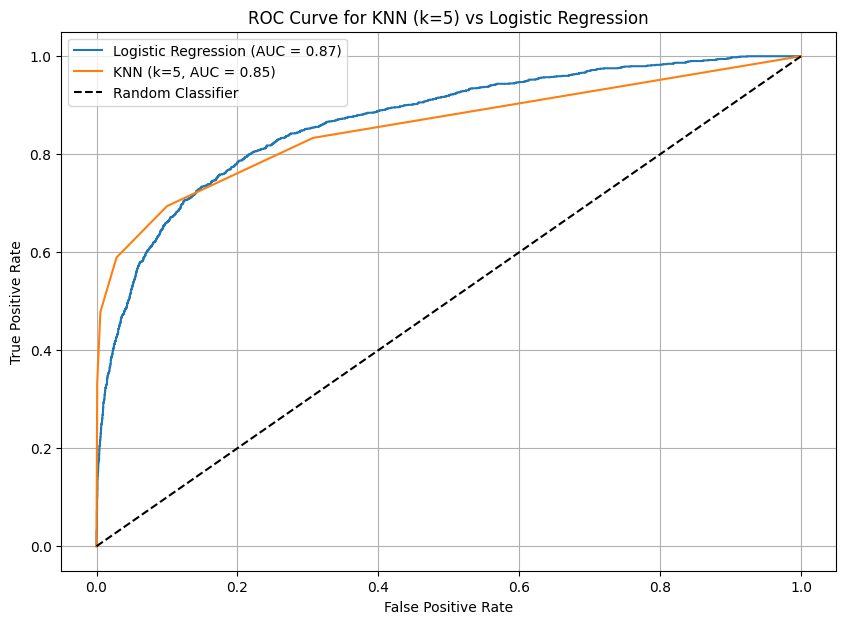


--- Results for k = 7 ---
Predicted labels: [0 0 0 ... 0 0 0]
Predicted probabilities: [0.         0.         0.         ... 0.28571429 0.28571429 0.14285714]
Confusion Matrix:
 [[4986  109]
 [ 600  822]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      5095
           1       0.88      0.58      0.70      1422

    accuracy                           0.89      6517
   macro avg       0.89      0.78      0.82      6517
weighted avg       0.89      0.89      0.88      6517



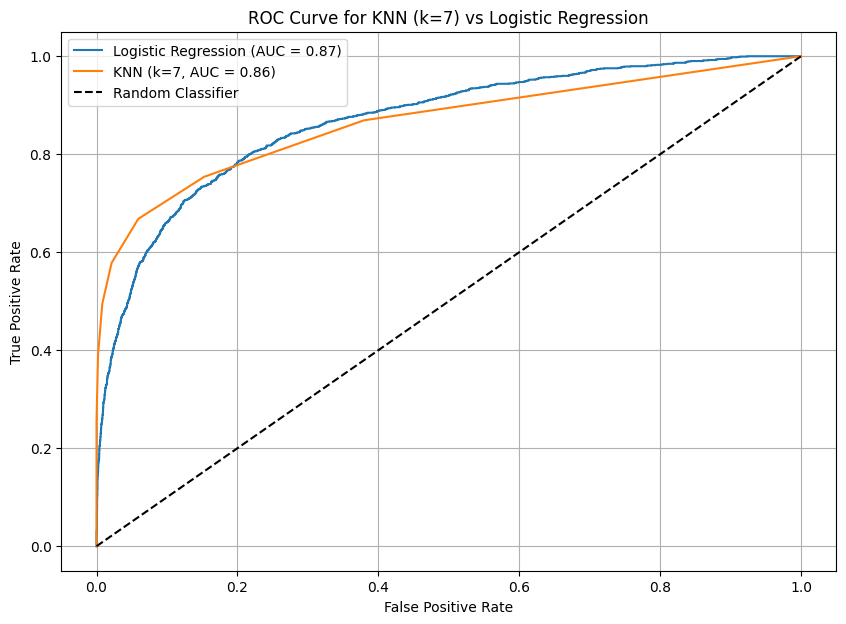


--- Results for k = 9 ---
Predicted labels: [0 0 0 ... 0 0 0]
Predicted probabilities: [0.         0.         0.         ... 0.22222222 0.33333333 0.11111111]
Confusion Matrix:
 [[5005   90]
 [ 604  818]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.94      5095
           1       0.90      0.58      0.70      1422

    accuracy                           0.89      6517
   macro avg       0.90      0.78      0.82      6517
weighted avg       0.89      0.89      0.88      6517



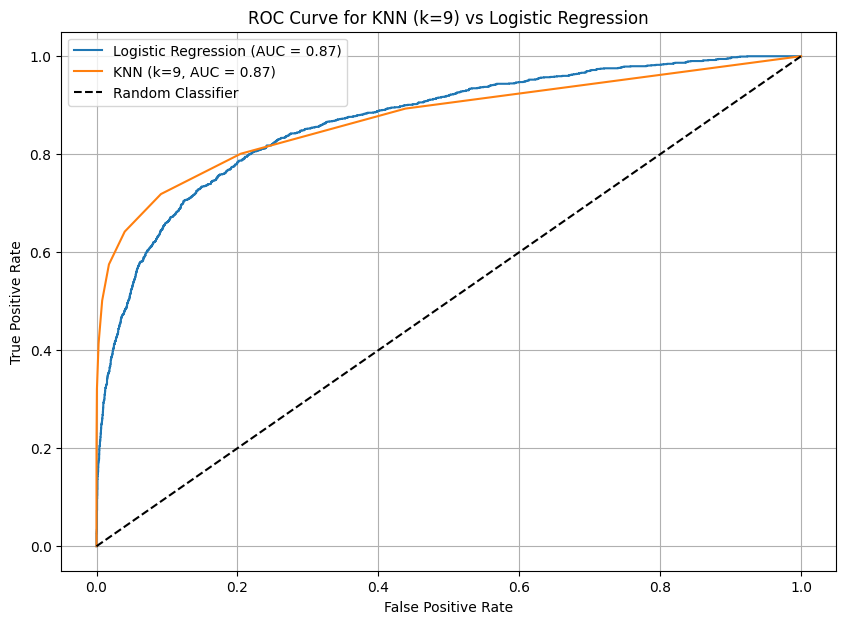


--- Results for k = 11 ---
Predicted labels: [0 0 0 ... 0 0 0]
Predicted probabilities: [0.         0.         0.         ... 0.18181818 0.36363636 0.09090909]
Confusion Matrix:
 [[5009   86]
 [ 615  807]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      5095
           1       0.90      0.57      0.70      1422

    accuracy                           0.89      6517
   macro avg       0.90      0.78      0.82      6517
weighted avg       0.89      0.89      0.88      6517



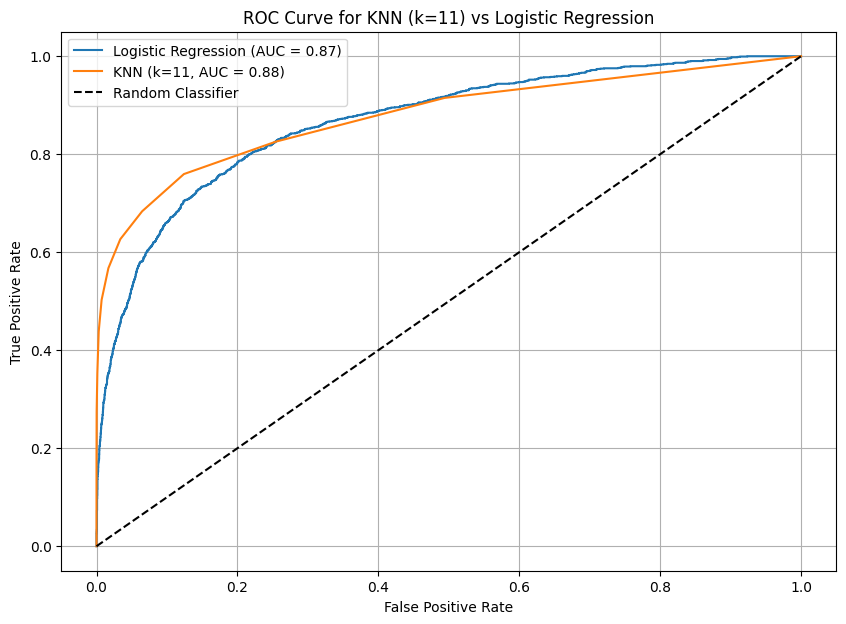

In [ ]:
for k in [3,5,7,9,11]: # Corrected: iterating over a list of specific k values
    modelk = KNeighborsClassifier(n_neighbors=k)
    modelk.fit(X_train_scaled,y_train)
    y_pred_k=modelk.predict(X_test_scaled)
    y_prob_k=modelk.predict_proba(X_test_scaled)[:,1]

    print(f"\n--- Results for k = {k} ---")
    print("Predicted labels:", y_pred_k)
    print("Predicted probabilities:", y_prob_k)

    cm_k = confusion_matrix(y_test,y_pred_k)
    print("Confusion Matrix:\n", cm_k)
    report_k = classification_report(y_test,y_pred_k)
    print("Classification Report:\n", report_k)

    fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob)
    auc_lr = roc_auc_score(y_test, y_prob)

    fpr_k, tpr_k, thresholds_k = roc_curve(y_test, y_prob_k)
    auc_k = roc_auc_score(y_test, y_prob_k)

    plt.figure(figsize=(10, 7))
    plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
    plt.plot(fpr_k, tpr_k, label=f'KNN (k={k}, AUC = {auc_k:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for KNN (k={k}) vs Logistic Regression')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Model Selection

Although KNN provides higher precision, Logistic Regression with threshold tuning achieves significantly higher recall, making it more suitable for identifying defaulters, which is critical in financial risk scenarios.

#### Observation

Increasing the value of k resulted in higher precision but reduced recall, indicating that the model became more conservative. Since the objective is to identify as many defaulters as possible, a lower k value performs better, but overall Logistic Regression remains the preferred model.

##SVM

In [ ]:
from sklearn.svm import SVC

model_svc = SVC(kernel='rbf',probability=True)

model_svc.fit(X_train_scaled,y_train)

SVC(probability=True)

In [ ]:
y_pred_svc=model_svc.predict(X_test_scaled)
y_prob_svc=model_svc.predict_proba(X_test_scaled)[:,1]

print(y_pred_svc)
print(y_prob_svc)

[0 0 0 ... 0 0 0]
[0.04379579 0.0269516  0.06140099 ... 0.07181059 0.20131113 0.05372989]


In [ ]:
cm_svc = confusion_matrix(y_test,y_pred_svc)
print(cm_svc)

[[5036   59]
 [ 510  912]]


In [ ]:
report_svc = classification_report(y_test,y_pred_svc)
print(report_svc)

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      5095
           1       0.94      0.64      0.76      1422

    accuracy                           0.91      6517
   macro avg       0.92      0.81      0.85      6517
weighted avg       0.91      0.91      0.91      6517



In [ ]:
fpr_svc,tpr_svc,thresholds_svc = roc_curve(y_test,y_prob_svc)
auc_svc = roc_auc_score(y_test,y_prob_svc)

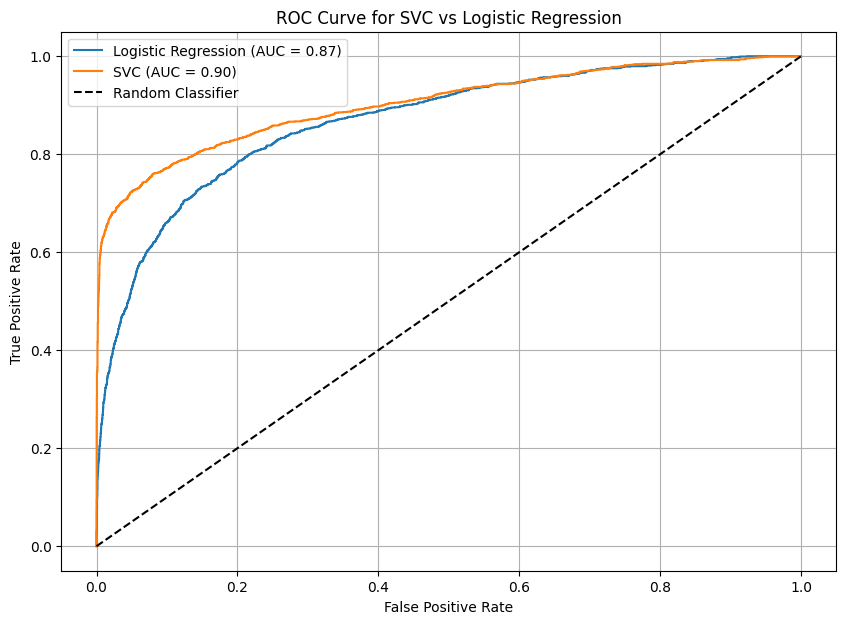

In [ ]:
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {auc_svc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for SVC vs Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

#### Observation -
The SVM model outperforms Logistic Regression as it has a higher AUC and a better ROC curve shape, indicating stronger class separation. It is more effective in distinguishing defaulters from non-defaulters across different thresholds.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 0.01]
}

svc = SVC()

grid = GridSearchCV(
    svc,
    param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 10, 'gamma': 0.1}


In [ ]:
grid.best_score_

np.float64(0.6772779985823972)

In [ ]:
grid.best_estimator_

SVC(C=10, gamma=0.1)

#### Model Selection -

Although SVM achieved a higher AUC, even after tuning, SVM < Logistic (in recall) .

Logistic Regression with threshold tuning provided better recall, making it more suitable for identifying defaulters in this scenario.


#### Model Comparison

Logistic Regression: Best recall after threshold tuning

KNN: High precision but lower recall

SVM: Strong class separation (high AUC) but slightly lower recall

### Key Insights

Dataset is imbalanced with fewer defaulters

Higher interest rate, loan burden, and past defaults increase risk

Lower loan grades are associated with higher default probability

### Final Model Selection

Logistic Regression with threshold tuning was selected as the final model due to its superior ability to identify defaulters (higher recall), which aligns with the business objective of minimizing financial risk.

### Business Recommendations

Flag high-risk applicants before approval

Apply stricter checks or pricing for risky customers

Prioritize recall to reduce financial loss

Continuously monitor and retrain the model